# 05 — Real-World Walk Test Statistics
**Indoor WiFi Fingerprinting Localization**

Analyse on-device predictions captured during a live walk through both floors:
- top-1 accuracy
- confusion matrix
- overall confidence distribution
- confidence on correct vs incorrect predictions
- mean confidence overall

Then plot four spatial maps of the run:
1. Correctly identified — Ground Floor (`MAP=0`)
2. Correctly identified — First Floor  (`MAP=1`)
3. Incorrectly identified — Ground Floor, with the true location and a line to the predicted location
4. Incorrectly identified — First Floor, same as above

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

In [2]:
ROOT     = Path('../../')
TEST_CSV = ROOT / 'Data' / '04_Testing'  / 'walk_test_2026-04-21.csv'
MAP_DIR  = ROOT / 'Data' / '03_Map_Data'
COORDS   = MAP_DIR / 'Coordinates.csv'
OUT_DIR  = ROOT / 'Data' / '04_Testing' / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Test CSV : {TEST_CSV.resolve()}')
print(f'Coords   : {COORDS.resolve()}')
print(f'Figures  : {OUT_DIR.resolve()}')

Test CSV : D:\Source_Codes\01_Ongoing\03_Indoor_Localization\Android\Data\04_Testing\walk_test_2026-04-21.csv
Coords   : D:\Source_Codes\01_Ongoing\03_Indoor_Localization\Android\Data\03_Map_Data\Coordinates.csv
Figures  : D:\Source_Codes\01_Ongoing\03_Indoor_Localization\Android\Data\04_Testing\figures


## 1. Load the walk test

In [3]:
df = pd.read_csv(TEST_CSV)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['correct']   = df['actual'] == df['predicted']

print(f'Total scans : {len(df)}')
print(f'Time span   : {df.timestamp.min()}  →  {df.timestamp.max()}')
print(f'Unique actual locations    : {df.actual.nunique()}')
print(f'Unique predicted locations : {df.predicted.nunique()}')
df.head()

Total scans : 58
Time span   : 2026-04-21 17:41:32.499604  →  2026-04-21 17:57:13.933194
Unique actual locations    : 49
Unique predicted locations : 49


,timestamp,actual,predicted,confidence,correct
0,2026-04-21 17:41:32.499604,DLT7/1,DLT7/1,0.662222,True
1,2026-04-21 17:41:43.332330,Between DLT7 and DLT8,Between DLT7 and DLT8,0.534444,True
2,2026-04-21 17:41:56.717121,DLT-8/1,DLT-8/1,0.676666,True
3,2026-04-21 17:42:22.522288,DLT8 Ramp,DLT8 Ramp,0.350000,True
4,2026-04-21 17:42:42.284188,Between DLT7 and DLT8,Between DLT7 and DLT8,0.536151,True


In [4]:
coords = pd.read_csv(COORDS)
coord_lookup = coords.set_index('Label')[['x', 'y', 'MAP']].to_dict('index')

missing_actual    = set(df.actual)    - set(coord_lookup)
missing_predicted = set(df.predicted) - set(coord_lookup)
print(f'Coordinate entries : {len(coord_lookup)}')
print(f'Missing actuals    : {missing_actual or "none"}')
print(f'Missing predicteds : {missing_predicted or "none"}')

Coordinate entries : 52
Missing actuals    : none
Missing predicteds : none


## 2. Top-1 accuracy

In [5]:
top1 = accuracy_score(df.actual, df.predicted)
n_correct, n_total = int(df.correct.sum()), len(df)

print(f'Top-1 accuracy : {top1:.1%}  ({n_correct}/{n_total})')
print(f'Errors         : {n_total - n_correct}')

Top-1 accuracy : 93.1%  (54/58)
Errors         : 4


## 3. Confusion matrix
Restricted to labels that actually appear in this walk so the matrix stays readable.

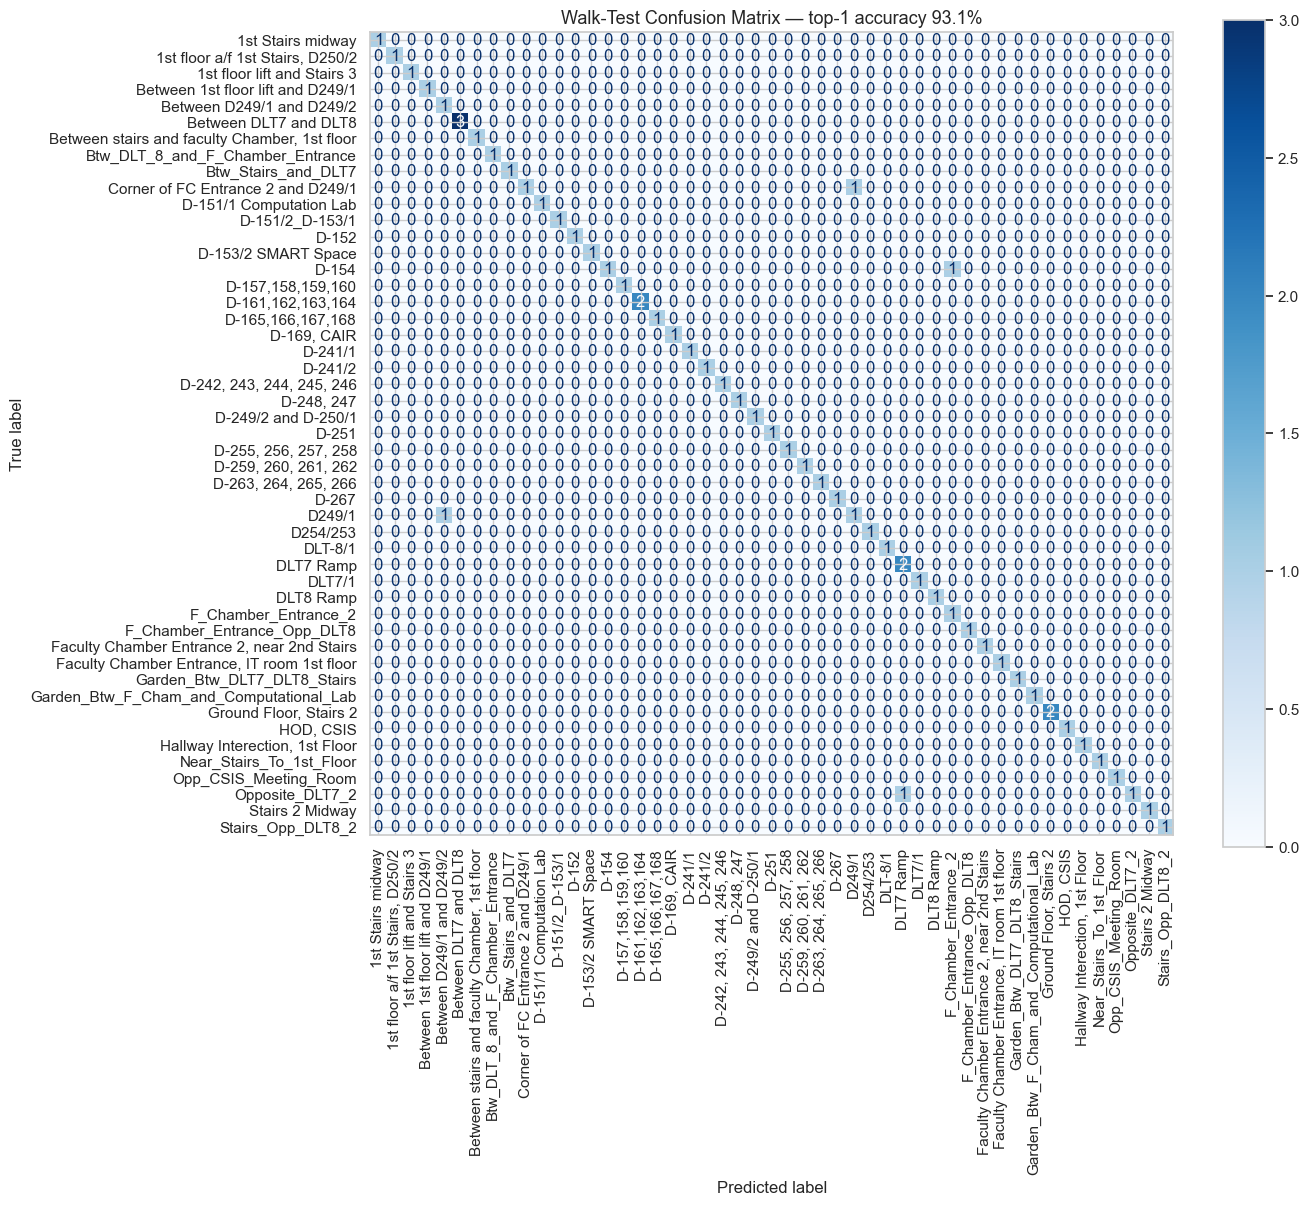

In [6]:
labels_in_run = sorted(set(df.actual) | set(df.predicted))
cm = confusion_matrix(df.actual, df.predicted, labels=labels_in_run)

fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay(cm, display_labels=labels_in_run).plot(
    ax=ax, colorbar=True, xticks_rotation=90, cmap='Blues', values_format='d'
)
ax.set_title(f'Walk-Test Confusion Matrix — top-1 accuracy {top1:.1%}', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=110)
plt.show()

## 4. Confidence statistics

In [7]:
mean_overall = df.confidence.mean()
mean_right   = df.loc[df.correct,  'confidence'].mean()
mean_wrong   = df.loc[~df.correct, 'confidence'].mean()

summary = pd.DataFrame({
    'count' : [n_total, n_correct, n_total - n_correct],
    'mean'  : [mean_overall, mean_right, mean_wrong],
    'median': [df.confidence.median(),
               df.loc[df.correct,  'confidence'].median(),
               df.loc[~df.correct, 'confidence'].median()],
    'min'   : [df.confidence.min(),
               df.loc[df.correct,  'confidence'].min(),
               df.loc[~df.correct, 'confidence'].min() if (~df.correct).any() else np.nan],
    'max'   : [df.confidence.max(),
               df.loc[df.correct,  'confidence'].max(),
               df.loc[~df.correct, 'confidence'].max() if (~df.correct).any() else np.nan],
}, index=['Overall', 'Correct', 'Incorrect'])

print(summary.round(3).to_string())
print(f'\nMean confidence (overall) : {mean_overall:.3f}')

           count   mean  median    min    max
Overall       58  0.612   0.612  0.291  0.933
Correct       54  0.630   0.632  0.318  0.933
Incorrect      4  0.378   0.349  0.291  0.523

Mean confidence (overall) : 0.612


### 4a. Overall confidence distribution

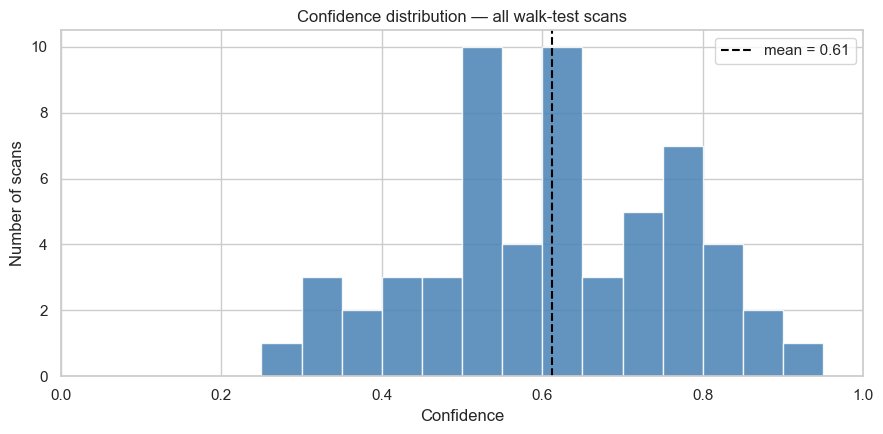

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df.confidence, bins=20, range=(0, 1), color='steelblue',
        edgecolor='white', alpha=0.85)
ax.axvline(mean_overall, color='black', linestyle='--',
           label=f'mean = {mean_overall:.2f}')
ax.set_xlim(0, 1)
ax.set_xlabel('Confidence')
ax.set_ylabel('Number of scans')
ax.set_title('Confidence distribution — all walk-test scans')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'confidence_distribution.png', dpi=110)
plt.show()

### 4b. Confidence: correct vs incorrect

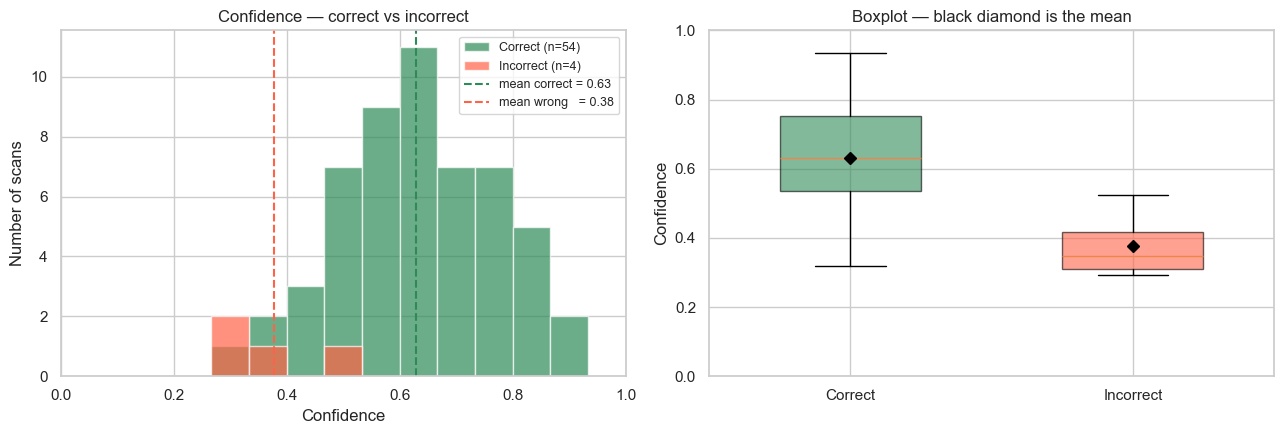

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Overlapping histograms
axes[0].hist(df.loc[df.correct,  'confidence'], bins=15, range=(0, 1),
             color='seagreen', alpha=0.7, label=f'Correct (n={n_correct})',
             edgecolor='white')
axes[0].hist(df.loc[~df.correct, 'confidence'], bins=15, range=(0, 1),
             color='tomato',   alpha=0.7, label=f'Incorrect (n={n_total - n_correct})',
             edgecolor='white')
axes[0].axvline(mean_right, color='seagreen', linestyle='--',
                label=f'mean correct = {mean_right:.2f}')
axes[0].axvline(mean_wrong, color='tomato',   linestyle='--',
                label=f'mean wrong   = {mean_wrong:.2f}')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Number of scans')
axes[0].set_title('Confidence — correct vs incorrect')
axes[0].legend(fontsize=9)

# Boxplot side-by-side
data = [df.loc[df.correct, 'confidence'], df.loc[~df.correct, 'confidence']]
bp = axes[1].boxplot(data, labels=['Correct', 'Incorrect'], patch_artist=True,
                     widths=0.5, showmeans=True,
                     meanprops={'marker': 'D', 'markerfacecolor': 'black',
                                'markeredgecolor': 'black', 'markersize': 6})
for patch, color in zip(bp['boxes'], ['seagreen', 'tomato']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Confidence')
axes[1].set_title('Boxplot — black diamond is the mean')

plt.tight_layout()
plt.savefig(OUT_DIR / 'confidence_correct_vs_wrong.png', dpi=110)
plt.show()

## 5. Spatial maps of the walk

In [10]:
# Attach coordinates and map index for both the actual and the predicted location
for col in ('actual', 'predicted'):
    df[f'{col}_x']   = df[col].map(lambda L: coord_lookup[L]['x'])
    df[f'{col}_y']   = df[col].map(lambda L: coord_lookup[L]['y'])
    df[f'{col}_map'] = df[col].map(lambda L: coord_lookup[L]['MAP'])

# Pre-load the two map images
maps = {0: np.array(Image.open(MAP_DIR / 'map_0.png')),
        1: np.array(Image.open(MAP_DIR / 'map_1.png'))}
MAP_NAMES = {0: 'Ground Floor', 1: 'First Floor'}

for k, m in maps.items():
    print(f'map_{k}.png : {MAP_NAMES[k]:<12}  shape={m.shape}')

map_0.png : Ground Floor  shape=(1024, 1536, 4)
map_1.png : First Floor   shape=(1024, 1536, 4)


In [11]:
def plot_correct(map_idx: int, ax=None, save: bool = True):
    """Plot all correctly-identified scans located on `map_idx`."""
    sub = df[df.correct & (df.actual_map == map_idx)]
    img = maps[map_idx]
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(13, 9))
    ax.imshow(img)
    if len(sub):
        sc = ax.scatter(sub.actual_x, sub.actual_y, c=sub.confidence,
                        cmap='Greens', vmin=0, vmax=1, s=140,
                        edgecolors='black', linewidths=1.2, zorder=3)
        plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label='Confidence')
    ax.set_title(f'Correctly identified — {MAP_NAMES[map_idx]}  '
                 f'(n={len(sub)})')
    ax.set_xticks([]); ax.set_yticks([])
    if own_fig:
        plt.tight_layout()
        if save:
            plt.savefig(OUT_DIR / f'map_correct_floor{map_idx}.png', dpi=120)
        plt.show()


def plot_incorrect(map_idx: int, ax=None, save: bool = True):
    """Plot incorrect scans whose *true* location is on `map_idx`.

    Each scan is drawn as:
      - a green circle at the ground-truth location
      - a red   X      at the predicted location (if also on this floor)
      - a dashed line connecting them when both are on the same floor
    Cross-floor mistakes are annotated next to the true point.
    """
    sub = df[(~df.correct) & (df.actual_map == map_idx)]
    img = maps[map_idx]
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(13, 9))
    ax.imshow(img)

    same_floor_legend_done = False
    for _, r in sub.iterrows():
        # ground truth
        ax.scatter(r.actual_x, r.actual_y, c='seagreen', s=160,
                   edgecolors='black', linewidths=1.2, zorder=4,
                   label='True location' if not same_floor_legend_done else None)
        if r.predicted_map == map_idx:
            # predicted on the same floor — draw line + X
            ax.plot([r.actual_x, r.predicted_x], [r.actual_y, r.predicted_y],
                    color='black', linestyle='--', linewidth=1.5, zorder=3)
            ax.scatter(r.predicted_x, r.predicted_y, c='tomato', s=180,
                       marker='X', edgecolors='black', linewidths=1.2,
                       zorder=5,
                       label='Predicted location' if not same_floor_legend_done else None)
        else:
            # cross-floor mistake — cannot draw the predicted point on this map
            ax.annotate(f'→ {r.predicted}\n({MAP_NAMES[r.predicted_map]})',
                        xy=(r.actual_x, r.actual_y),
                        xytext=(10, 10), textcoords='offset points',
                        fontsize=8, color='darkred',
                        bbox=dict(boxstyle='round,pad=0.3',
                                  fc='white', ec='darkred', alpha=0.8))
        same_floor_legend_done = True

    ax.set_title(f'Incorrectly identified — {MAP_NAMES[map_idx]}  '
                 f'(n={len(sub)})')
    ax.set_xticks([]); ax.set_yticks([])
    if len(sub):
        ax.legend(loc='lower right', framealpha=0.9)
    if own_fig:
        plt.tight_layout()
        if save:
            plt.savefig(OUT_DIR / f'map_incorrect_floor{map_idx}.png', dpi=120)
        plt.show()

print('Plot helpers ready.')

Plot helpers ready.


### 5a. Correctly identified — Ground Floor

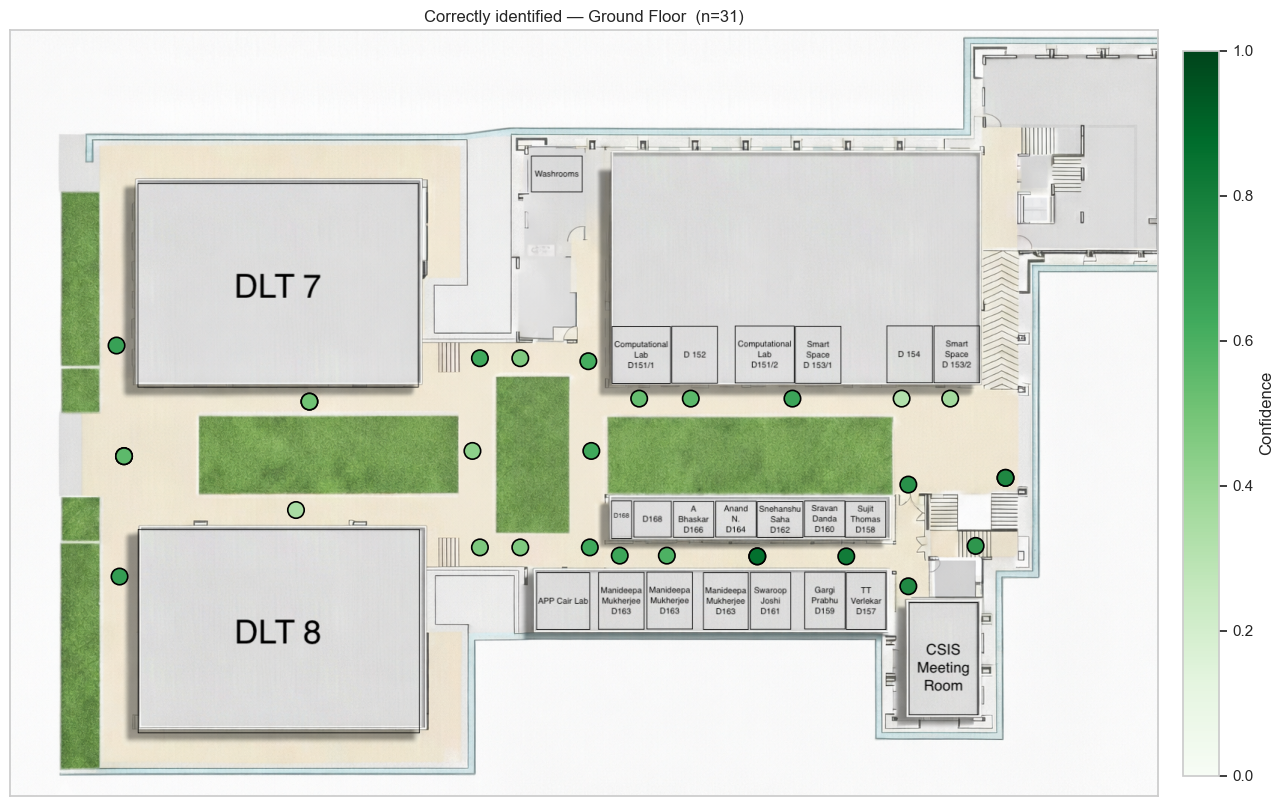

In [12]:
plot_correct(0)

### 5b. Correctly identified — First Floor

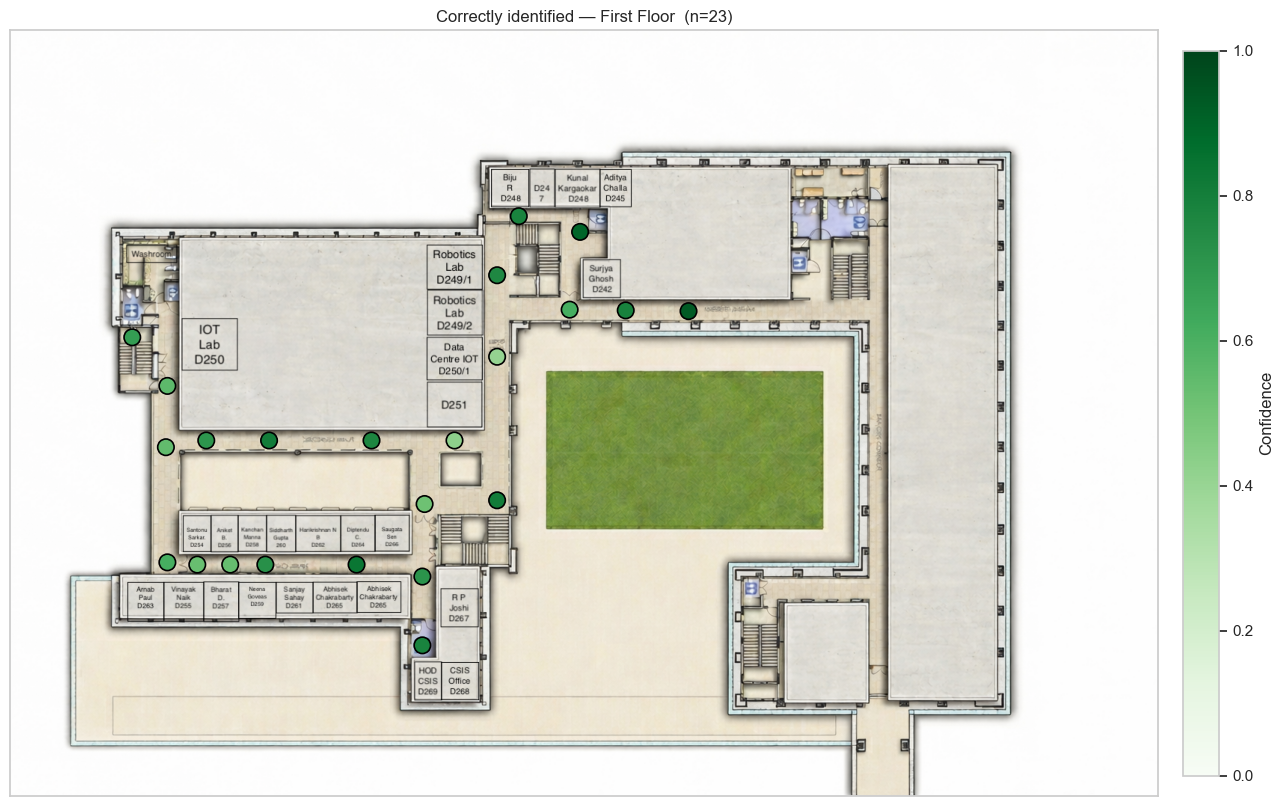

In [13]:
plot_correct(1)

### 5c. Incorrectly identified — Ground Floor
Green dot = where the user actually was. Red × = where the model placed them.
Dashed line shows the localisation error.

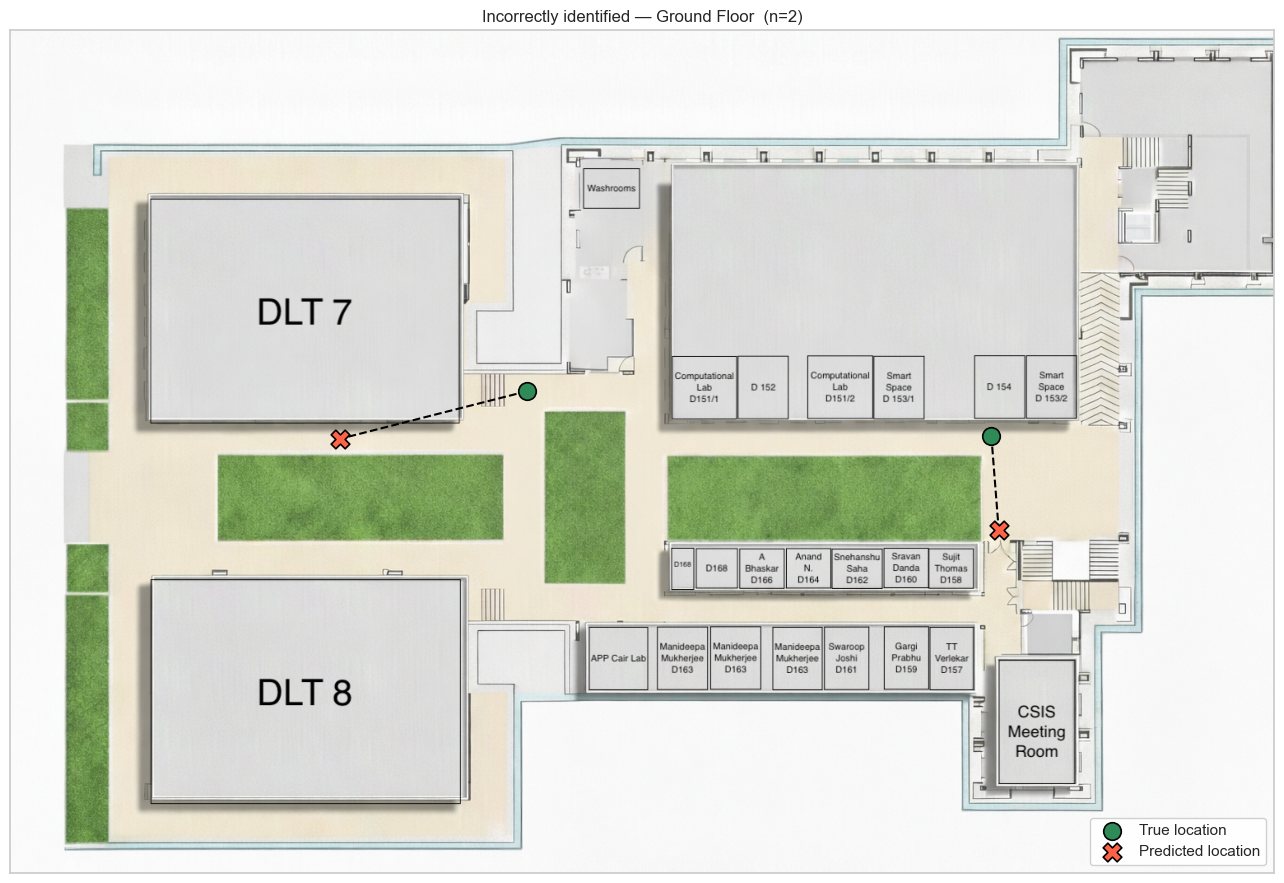

In [14]:
plot_incorrect(0)

### 5d. Incorrectly identified — First Floor

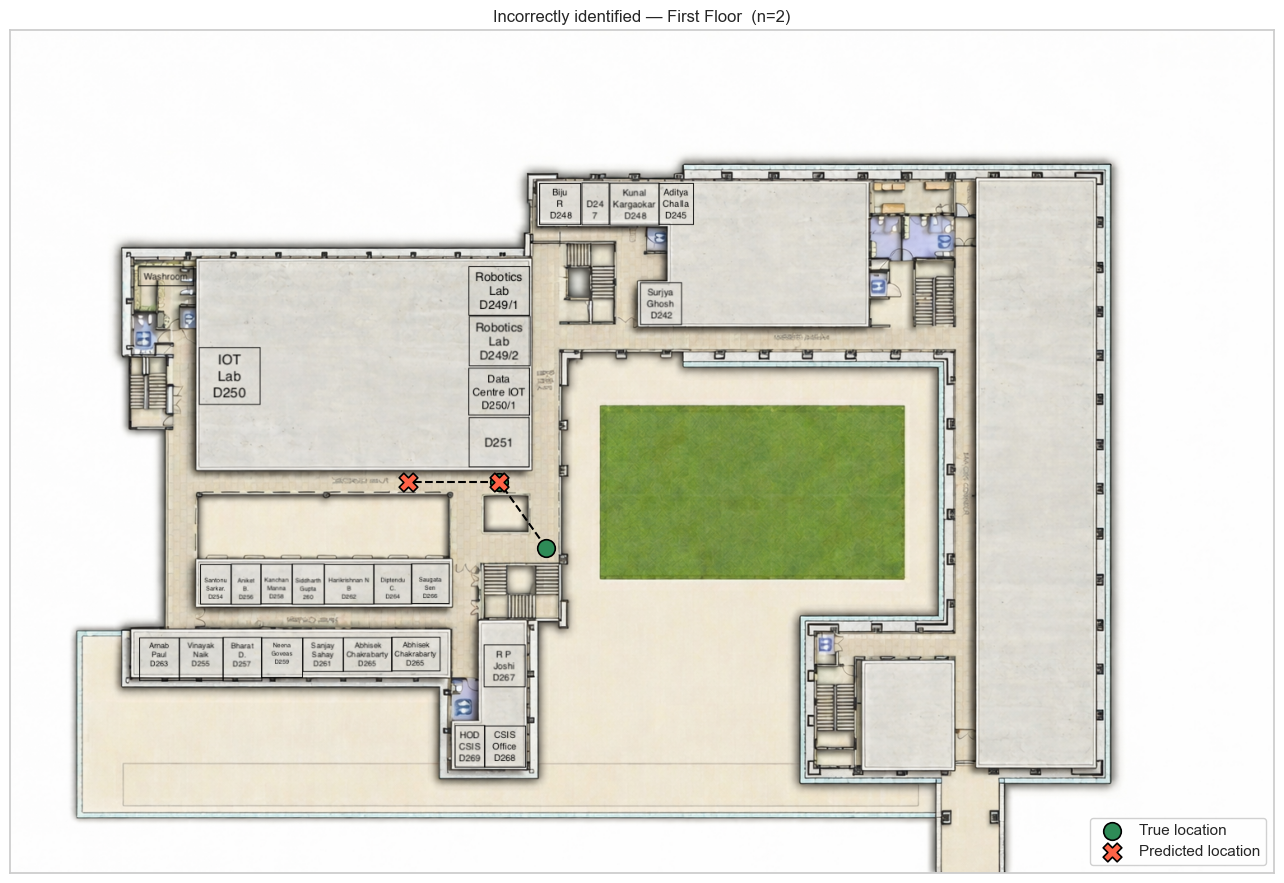

In [15]:
plot_incorrect(1)